# Pedestrian Crossing-Intent Prediction with a Vision-Language Model (JAAD)

Can a small vision-language model read a dashcam clip and say whether a pedestrian is about to cross, with a structured explanation, fast enough for a driving stack?
This project builds and measures the full chain:

1. **Dataset.** 655 short clips of JAAD pedestrians, each paired with a context prompt and a structured JSON target generated from JAAD's behaviour annotations.
2. **Fine-tuning.** QLoRA (4-bit NF4, LoRA r = 16) on Qwen2-VL-2B-Instruct over 524 training clips.
3. **Held-out evaluation.** 131 test clips, comparing the fine-tuned model against the zero-shot base model and a majority-class baseline.
4. **Real-time architecture.** A YOLO11s pedestrian tracker as the fast loop, with the VLM called asynchronously only when a new pedestrian appears. Telemetry was logged over all 346 JAAD videos (79,344 frames).

| Held-out test set (131 clips) | Base model, zero-shot | **LoRA fine-tuned** |
|---|---|---|
| Valid JSON output | 56.5% | **100%** |
| Accuracy (always "Crossing" scores **78.6%**) | 53.4% | 77.1% |
| Balanced accuracy | 52.2% | 51.6% |
| Recall on "Not Crossing" | 50.0% | 7.1% |

| Real-time loop (346 videos) | Value |
|---|---|
| Tracker loop latency, VLM idle | p50 17.9 ms · p95 20.4 ms |
| Tracker loop latency, VLM running on the same GPU | p50 20.2 ms · **p95 296 ms** |
| VLM call latency | p50 824 ms · p95 1,122 ms |

**Takeaways.** Fine-tuning taught the model the output *format* (100% valid JSON, every field filled), but **not the decision**: it answers
"Crossing" for 125 of 131 clips and is no better than the majority baseline. The asynchronous design keeps the tracker from ever blocking,
but the shared GPU still inflates its tail latency about 14×. Sections 3–4 break both results down.

**How to read this notebook.** Result cells run on artefacts in `results/` and `splits/`. Dataset generation, fine-tuning, evaluation and the
real-time loop need the JAAD videos and a CUDA GPU (runs were done on an RTX 5080) and were not re-executed here. The held-out evaluation
(`src/eval_intent_heldout.py`) was run while this repository was packaged; everything else is from the original runs.

## 0 · Setup

In [ ]:
import io, json, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Markdown, display, Image as IPyImage

RESULTS = Path("results")          # everything saved from the original runs lives here
FIG = RESULTS / "figures"

def show(path, width=1100, caption=None):
    """Display a saved result image, downscaled so the notebook stays small."""
    im = Image.open(path).convert("RGB")
    if im.width > width:
        im = im.resize((width, round(im.height * width / im.width)), Image.LANCZOS)
    buf = io.BytesIO(); im.save(buf, format="JPEG", quality=85)
    if caption:
        display(Markdown(f"*{caption}*"))
    display(IPyImage(data=buf.getvalue(), format="jpeg"))

def show_pair(left, right, titles=("", ""), width=1400, gap=12):
    """Two result images side by side (e.g. ground truth vs prediction), embedded as one JPEG."""
    ims = [Image.open(p).convert("RGB") for p in (left, right)]
    h = min(im.height for im in ims)
    ims = [im.resize((round(im.width * h / im.height), h), Image.LANCZOS) for im in ims]
    canvas = Image.new("RGB", (ims[0].width + gap + ims[1].width, h), (252, 252, 251))
    canvas.paste(ims[0], (0, 0)); canvas.paste(ims[1], (ims[0].width + gap, 0))
    if canvas.width > width:
        canvas = canvas.resize((width, round(canvas.height * width / canvas.width)), Image.LANCZOS)
    buf = io.BytesIO(); canvas.save(buf, format="JPEG", quality=85)
    if any(titles):
        display(Markdown(f"*Left: {titles[0]} · Right: {titles[1]}*"))
    display(IPyImage(data=buf.getvalue(), format="jpeg"))

# Chart style: light surface, hairline grid, text in ink colours, fixed categorical order.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "legend.frameon": False,
    "axes.prop_cycle": mpl.cycler(color=SERIES), "figure.dpi": 110, "savefig.dpi": 160,
})

SPLITS = Path("splits")
M = RESULTS / "metrics"
def load_jsonl(p): return [json.loads(l) for l in open(p)]
train, test = load_jsonl(SPLITS / "v2_train.jsonl"), load_jsonl(SPLITS / "v2_test.jsonl")

## 1 · Dataset: JAAD clips → prompts → structured targets (`src/build_intent_dataset.py`)

JAAD provides per-frame pedestrian boxes, behaviour tags (walking/standing, looking), demographics, and traffic and ego-vehicle state for 346 dashcam videos.
For every *behaviour-annotated* pedestrian with at least 15 frames, the builder:

* cuts the **15 frames just before the pedestrian's decision point**, which is 0.5 s of 30 fps video;
* writes a **context prompt** from the annotations at the decision frame: ego-vehicle state, traffic light, stop sign, crosswalk;
* writes a **JSON target** with demographics, appearance (backpack / phone / facing camera), attention (looking at vehicle), motion
  (walking / standing), `intent` (the JAAD `crossing` attribute), `confidence_score` and a one-line `reasoning`.

Two properties of the targets matter when reading the results. First, `confidence_score` is **sampled uniformly from 0.85–0.99**, so it is not a calibrated
probability and the model's "confidence" should not be read as one. Second, `reasoning` is a **template** filled from the same annotations, so it is a structured
explanation rather than free-form causal reasoning.

In [ ]:
import cv2, random
from tqdm import tqdm
from jaad_data import JAAD          # JAAD's own interface: run from a clone of https://github.com/ykotseruba/JAAD

FRAMES_PER_CLIP = 15
db = JAAD(data_path=".").generate_database()
examples = []
for vid_id, vid in tqdm(db.items()):
    cap = cv2.VideoCapture(f"JAAD_clips/{vid_id}.mp4")
    fps, w, h = cap.get(cv2.CAP_PROP_FPS), int(cap.get(3)), int(cap.get(4))
    for ped_id, ped in vid["ped_annotations"].items():
        frames = ped.get("frames", [])
        if "b" not in ped_id or len(frames) < FRAMES_PER_CLIP:
            continue
        attrs = ped.get("attributes", {})
        decision = attrs.get("decision_point", -1)
        decision = frames[-1] if decision == -1 else decision
        if decision not in frames or (d := frames.index(decision)) < FRAMES_PER_CLIP:
            continue
        ego = {0: "stopped", 1: "moving slowly", 2: "moving fast", 3: "decelerating", 4: "accelerating"}.get(vid.get("vehicle_annotations", {}).get(decision, 0), "moving")
        traffic = vid.get("traffic_annotations", {}).get(decision, {})
        light = {0: "none", 1: "red", 2: "green"}.get(traffic.get("traffic_light", 0), "none")
        # ... demographics / appearance / attention / motion text built from the annotations (see src/build_intent_dataset.py)
        target = {"intent": "Crossing" if attrs.get("crossing", 0) > 0 else "Not Crossing",
                  "confidence_score": round(random.uniform(0.85, 0.99), 2)}          # NOTE: random, not a probability
        # write frames[d-15:d] to v2_training_clips/<vid>_<ped>.mp4 and append {"messages": [user(video + prompt), assistant(json)]}

In [1]:
def intent(ex): return json.loads(ex["messages"][1]["content"][0]["text"])["intent"]
def source(ex): return Path(ex["messages"][0]["content"][0]["video"]).name.split("_0_")[0]

split = pd.DataFrame({
    "clips": [len(train), len(test)],
    "Crossing": [sum(intent(e) == "Crossing" for e in train), sum(intent(e) == "Crossing" for e in test)],
    "Not Crossing": [sum(intent(e) == "Not Crossing" for e in train), sum(intent(e) == "Not Crossing" for e in test)],
    "source videos": [len({source(e) for e in train}), len({source(e) for e in test})],
}, index=["train", "test"])
shared = {source(e) for e in test} & {source(e) for e in train}
display(split)
print(f"clip overlap between splits: {len({e['messages'][0]['content'][0]['video'] for e in train} & {e['messages'][0]['content'][0]['video'] for e in test})}")
print(f"test clips whose source video also appears in training: {sum(source(e) in shared for e in test)} / {len(test)} (different pedestrians, same scene)")
print(f"majority-class accuracy on test: {split.loc['test', 'Crossing'] / len(test):.3f}")

,clips,Crossing,Not Crossing,source videos
train,524,384,140,283
test,131,103,28,105


clip overlap between splits: 0
test clips whose source video also appears in training: 101 / 131 (different pedestrians, same scene)
majority-class accuracy on test: 0.786


In [2]:
ex = test[0]
print("PROMPT:\n" + ex["messages"][0]["content"][1]["text"] + "\n")
print("TARGET:\n" + json.dumps(json.loads(ex["messages"][1]["content"][0]["text"]), indent=2))

PROMPT:
You are an autonomous driving system. The ego-vehicle is decelerating. The traffic light is green. Analyze the pedestrian in this video. Respond ONLY with a valid JSON object matching the exact schema: {"pedestrian_demographics": "<text>", "pedestrian_appearance": "<text>", "pedestrian_attention": "<text>", "pedestrian_motion": "<text>", "intent": "Crossing" | "Not Crossing", "confidence_score": <float>, "reasoning": "<text>"}.

TARGET:
{
  "pedestrian_demographics": "Young Adult Female",
  "pedestrian_appearance": "standard clothing",
  "pedestrian_attention": "Not looking at vehicle",
  "pedestrian_motion": "Walking",
  "intent": "Crossing",
  "confidence_score": 0.85,
  "reasoning": "The young adult female is walking and not looking at vehicle. The ego-vehicle is decelerating."
}


## 2 · QLoRA fine-tuning of Qwen2-VL-2B (`src/train_lora_v2.py`)

The base model is loaded in 4-bit NF4 with bf16 compute. LoRA adapters (r = 16, α = 32, dropout 0.05) go on all attention and MLP projections.
Training uses the paged 8-bit AdamW optimiser, LR 2e-4, batch 1 × 4 gradient accumulation, 5 epochs, gradient checkpointing, and bf16.
`qwen_vl_utils.process_vision_info` samples each clip at fps = 1, so the model sees **4 frames** (364×672) of the 0.5-second clip.

In [ ]:
import torch
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from qwen_vl_utils import process_vision_info
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2VLForConditionalGeneration, Trainer, TrainingArguments

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.bfloat16)
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2VLForConditionalGeneration.from_pretrained(MODEL_ID, quantization_config=bnb, device_map="auto", torch_dtype=torch.bfloat16)
model = get_peft_model(prepare_model_for_kbit_training(model), LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]))

def collate(examples):
    msgs = [e["messages"] for e in examples]
    texts = [processor.apply_chat_template(m, tokenize=False, add_generation_prompt=False) for m in msgs]
    images, videos = process_vision_info(msgs)
    batch = processor(text=texts, images=images, videos=videos, padding=True, return_tensors="pt")
    labels = batch["input_ids"].clone(); labels[labels == processor.tokenizer.pad_token_id] = -100
    batch["labels"] = labels
    return batch

Trainer(model=model, data_collator=collate, train_dataset=load_dataset("json", data_files="splits/v2_train.jsonl", split="train"),
        args=TrainingArguments(output_dir="qwen-pedestrian-intent-v2", per_device_train_batch_size=1, gradient_accumulation_steps=4,
                               learning_rate=2e-4, num_train_epochs=5, optim="paged_adamw_8bit", bf16=True, logging_steps=5,
                               save_strategy="epoch", gradient_checkpointing=True, report_to="none", remove_unused_columns=False)).train()

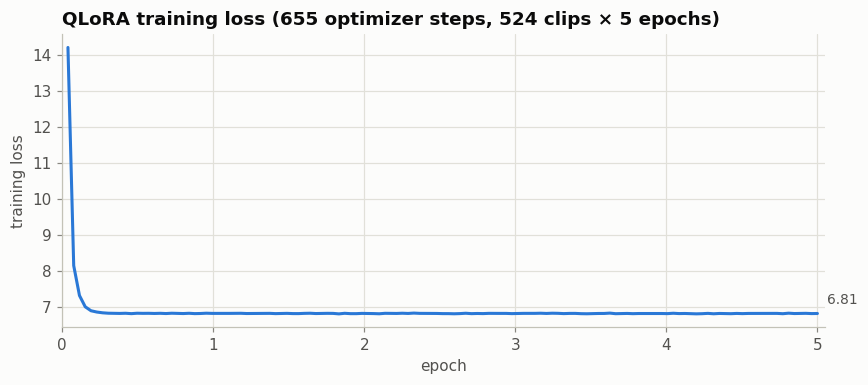

In [3]:
state = json.load(open(M / "lora_trainer_state.json"))
log = pd.DataFrame([l for l in state["log_history"] if "loss" in l])
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(log["epoch"], log["loss"], color=SERIES[0])
ax.set_xlabel("epoch"); ax.set_ylabel("training loss"); ax.set_xlim(0, 5.05)
ax.set_title(f"QLoRA training loss ({state['global_step']} optimizer steps, 524 clips × 5 epochs)")
ax.annotate(f"{log['loss'].iloc[-1]:.2f}", (log["epoch"].iloc[-1], log["loss"].iloc[-1]), xytext=(6, 6), textcoords="offset points", fontsize=9, color=INK2)
plt.tight_layout(); fig.savefig(FIG / "lora_training_loss.png"); plt.show()

The loss falls from 14.2 to 7.3 within the first tenth of an epoch, then stays flat at 6.8 for the remaining 4.9 epochs. The collator masks
**only padding**, so every token in the sequence is a training target. That includes the prompt and the video placeholder tokens: about 1,440 of the
~1,650 tokens in a training example are `<|video_pad|>`, and the answer JSON is ~5% of the loss. The intent word itself is a fraction of a percent.

## 3 · Held-out evaluation (`src/eval_intent_heldout.py`)

All 131 test clips are run through (a) the base model zero-shot and (b) base + LoRA adapter. Both use the same prompt, the same 4-bit loading and
video sampling as training, and greedy decoding. `intent` is read from the JSON, with a keyword fallback when the output is not valid JSON.

In [ ]:
!python src/eval_intent_heldout.py --mode base
!python src/eval_intent_heldout.py --mode lora

In [4]:
summ = {m: json.load(open(M / f"heldout_summary_{m}.json")) for m in ("base", "lora")}
cols = {"valid_json_rate": "valid JSON", "accuracy": "accuracy", "balanced_accuracy": "balanced accuracy",
        "macro_f1": "macro-F1", "recall_crossing": "recall: Crossing", "recall_not_crossing": "recall: Not Crossing",
        "latency_mean_ms": "latency mean (ms)"}
table = pd.DataFrame({name: {v: summ[m][k] for k, v in cols.items()} for m, name in (("base", "base, zero-shot"), ("lora", "LoRA fine-tuned"))}).T
display(table.round(3))
print(f"majority baseline (always 'Crossing'): accuracy {summ['lora']['majority_baseline_accuracy']:.3f}, balanced accuracy 0.500")

,valid JSON,accuracy,balanced accuracy,macro-F1,recall: Crossing,recall: Not Crossing,latency mean (ms)
"base, zero-shot",0.565,0.534,0.522,0.481,0.544,0.500,1351.434
LoRA fine-tuned,1.000,0.771,0.516,0.493,0.961,0.071,2152.898


majority baseline (always 'Crossing'): accuracy 0.786, balanced accuracy 0.500


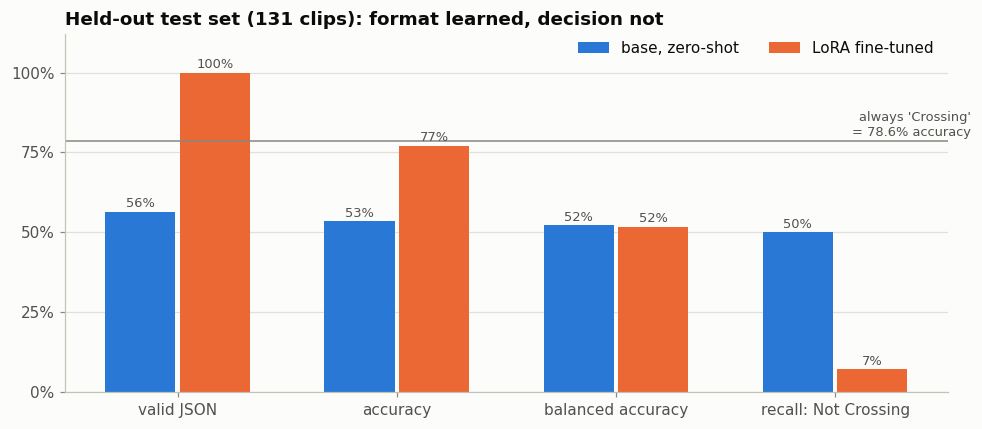

In [5]:
metrics = ["valid JSON", "accuracy", "balanced accuracy", "recall: Not Crossing"]
x = np.arange(len(metrics)); w = 0.32
fig, ax = plt.subplots(figsize=(9, 4))
for j, (name, color) in enumerate(zip(table.index, SERIES)):
    vals = table.loc[name, metrics].astype(float).values
    bars = ax.bar(x + (j - 0.5) * (w + 0.02), vals, width=w, color=color, label=name)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.0%}", ha="center", fontsize=8.5, color=INK2)
ax.axhline(summ["lora"]["majority_baseline_accuracy"], color=MUTED, lw=1)
ax.text(3.62, summ["lora"]["majority_baseline_accuracy"] + 0.015, "always 'Crossing'\n= 78.6% accuracy", fontsize=8.5, color=INK2, ha="right")
ax.set_xticks(x, metrics); ax.set_ylim(0, 1.12); ax.set_yticks([0, .25, .5, .75, 1], ["0%", "25%", "50%", "75%", "100%"])
ax.set_title("Held-out test set (131 clips): format learned, decision not")
ax.legend(loc="upper right", ncol=2, bbox_to_anchor=(1, 1.02))
ax.grid(axis="x", visible=False)
plt.tight_layout(); fig.savefig(FIG / "heldout_evaluation.png"); plt.show()

In [6]:
preds = {m: pd.read_csv(M / f"heldout_predictions_{m}.csv") for m in ("base", "lora")}
for m, name in (("base", "base, zero-shot"), ("lora", "LoRA fine-tuned")):
    cm = pd.crosstab(preds[m]["truth"], preds[m]["pred"], rownames=["truth"], colnames=[f"{name}: predicted"])
    display(cm)

"base, zero-shot: predicted",Crossing,Not Crossing
truth,,
Crossing,56,47
Not Crossing,14,14


LoRA fine-tuned: predicted,Crossing,Not Crossing
truth,,
Crossing,99,4
Not Crossing,26,2


In [7]:
check = json.load(open(M / "heldout_summary_lora_trainpreproc.json"))
print("Robustness check: training used the processor defaults (fps 2, full resolution, ~1,440 video tokens), while the evaluator above follows")
print("master_evaluator.py (fps 1, 256²–512² pixels). Re-running the LoRA model with the training-time settings:")
print({k: round(check[k], 3) for k in ("accuracy", "balanced_accuracy", "recall_not_crossing", "valid_json_rate")}, "-> same conclusion")

Robustness check: training used the processor defaults (fps 2, full resolution, ~1,440 video tokens), while the evaluator above follows
master_evaluator.py (fps 1, 256²–512² pixels). Re-running the LoRA model with the training-time settings:
{'accuracy': 0.756, 'balanced_accuracy': 0.507, 'recall_not_crossing': 0.071, 'valid_json_rate': 1.0} -> same conclusion


Held-out clips with the fine-tuned model's raw output, one image per clip. This is the "dashboard" view the project renders for every clip
(`src/render_dashboards.py`), here with the ground truth added. Three are correct and one is wrong.

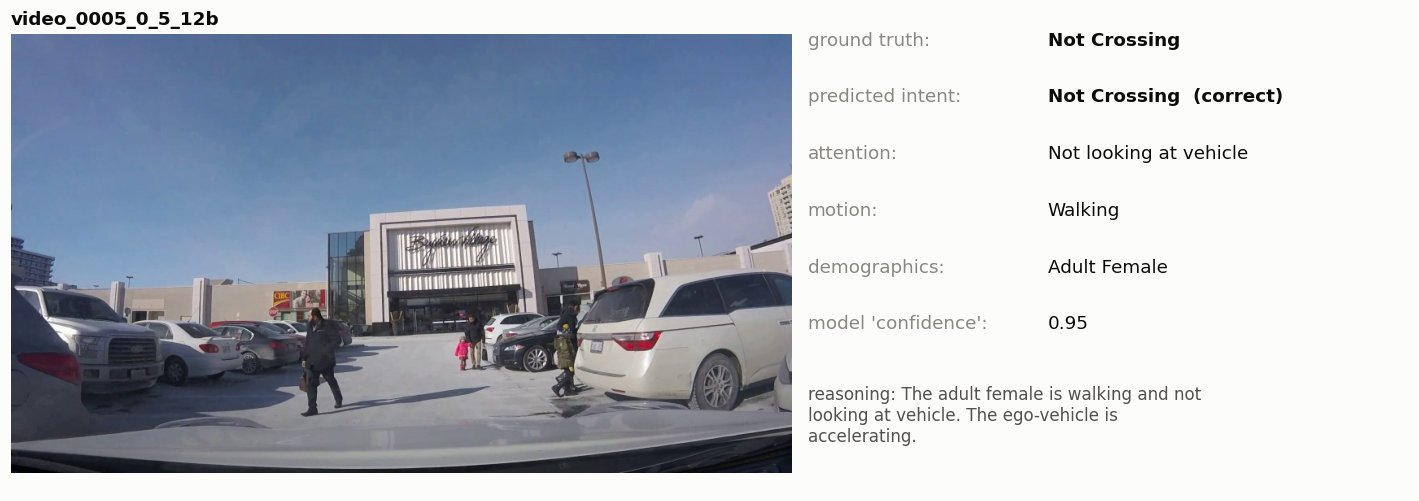

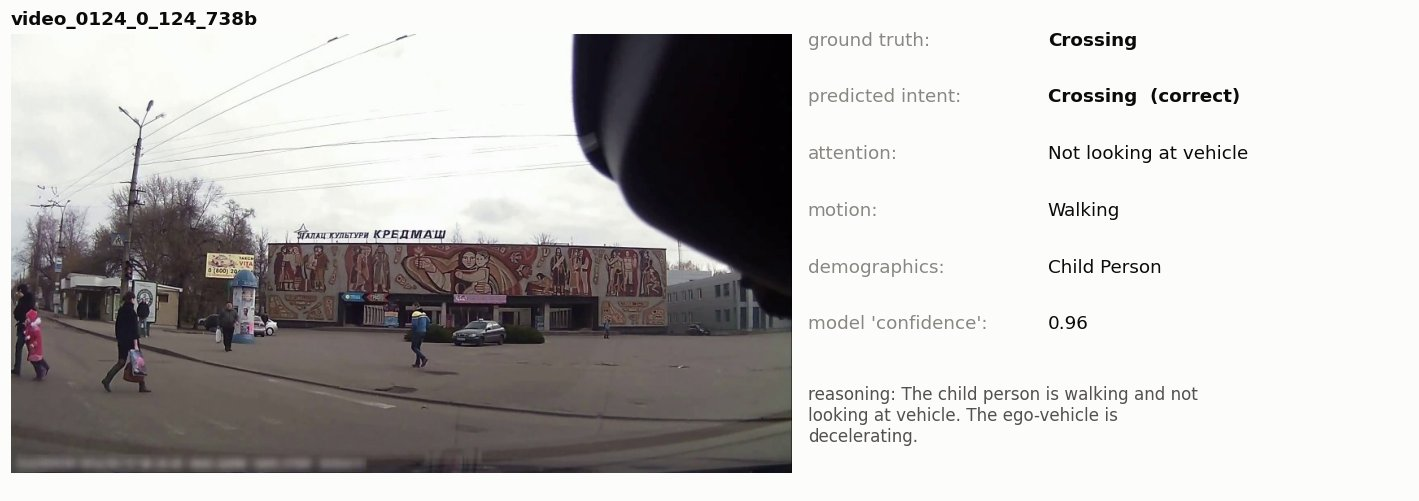

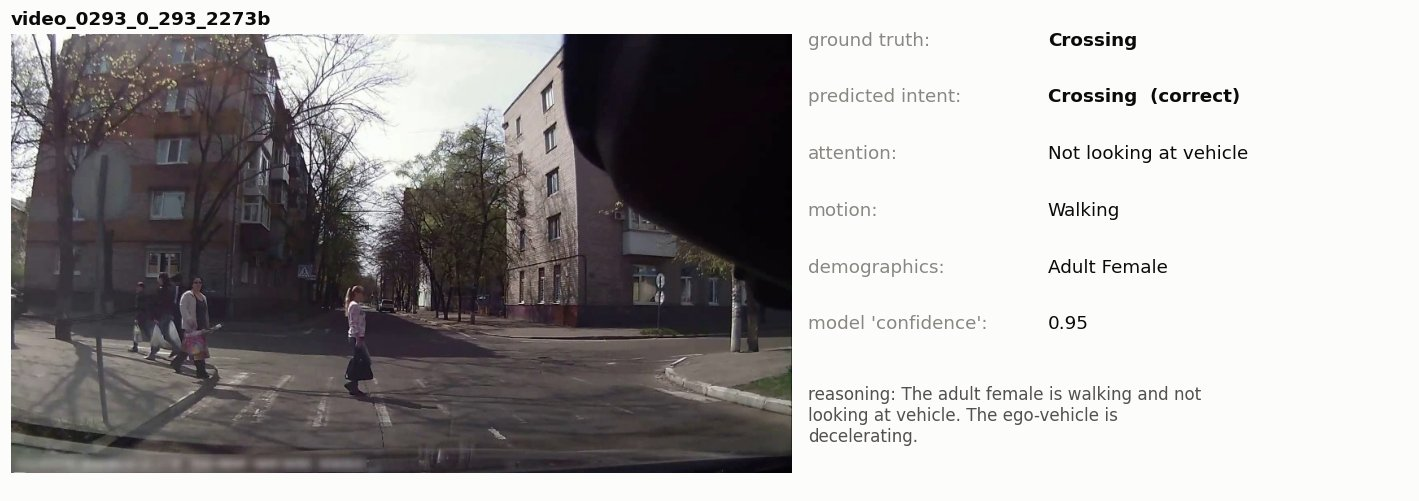

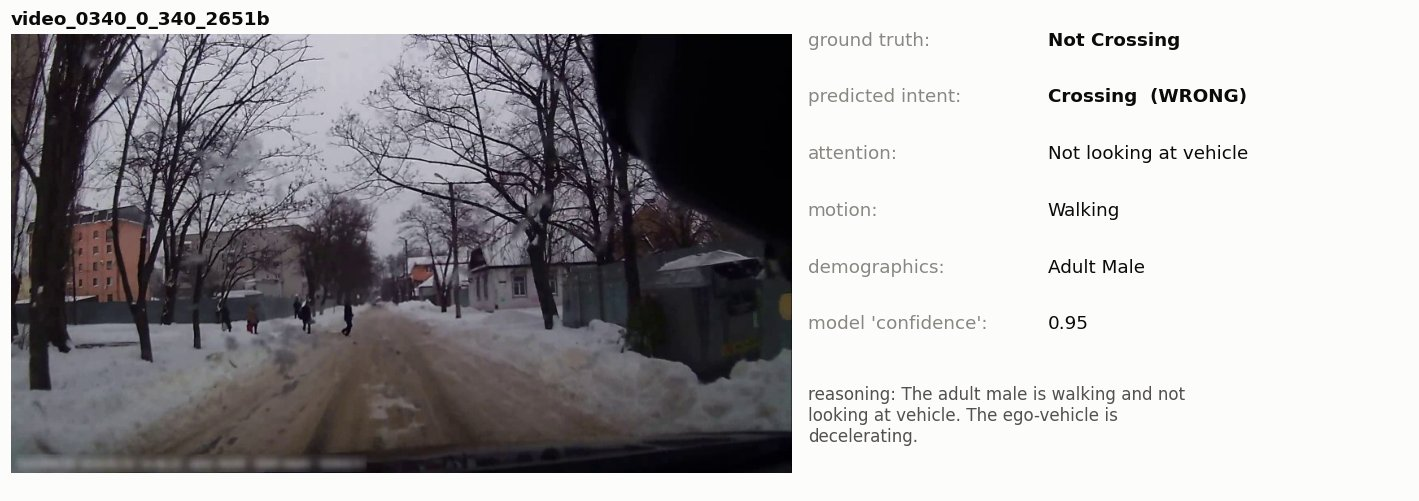

In [8]:
import textwrap
lora = preds["lora"].set_index("clip")
cases = [p.name.replace(".jpg", ".mp4") for p in sorted((FIG / "heldout_frames").glob("*.jpg"))]
for clip in cases:
    row = lora.loc[clip]; out = json.loads(row["raw_output"])
    fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.3, 1]})
    ax_img.imshow(Image.open(FIG / "heldout_frames" / clip.replace(".mp4", ".jpg"))); ax_img.axis("off")
    ax_img.set_title(clip.replace(".mp4", ""), fontsize=12)
    ax_txt.axis("off")
    verdict = "correct" if row["correct"] else "WRONG"
    lines = [("ground truth", row["truth"]), ("predicted intent", f'{out["intent"]}  ({verdict})'),
             ("attention", out["pedestrian_attention"]), ("motion", out["pedestrian_motion"]),
             ("demographics", out["pedestrian_demographics"]), ("model 'confidence'", out["confidence_score"])]
    for i, (k, v) in enumerate(lines):
        ax_txt.text(0, 0.94 - i * 0.12, f"{k}:", fontsize=12, color=MUTED, transform=ax_txt.transAxes)
        ax_txt.text(0.4, 0.94 - i * 0.12, str(v), fontsize=12, color=INK, weight="semibold" if i < 2 else "normal", transform=ax_txt.transAxes)
    ax_txt.text(0, 0.94 - len(lines) * 0.12, textwrap.fill("reasoning: " + out["reasoning"], 50), fontsize=11, color=INK2, va="top", transform=ax_txt.transAxes)
    plt.tight_layout(); fig.savefig(FIG / f"heldout_case_{clip.replace('.mp4', '')}.png"); plt.show()

**Why the decision did not transfer.**

* **Loss masking.** Labels cover the prompt and ~1,440 video placeholder tokens, and the answer is ~5% of the loss. Masking everything except the
  assistant's answer is the first fix.
* **Imbalance.** 73% of training clips are "Crossing". With a mostly template target, the cheapest way to lower the loss is to emit the majority label.
* **Little temporal evidence.** 4 frames over 0.5 s, ending at the decision point, often cannot show whether someone is about to step off the kerb.
* **Label semantics.** JAAD's `crossing` attribute says whether the pedestrian crosses *at some point*, not what happens right after the clip.
* **Noisy auxiliary targets.** The random `confidence_score` and templated `reasoning` spend capacity on text that carries no signal.

Next experiments: class-balanced sampling or a weighted loss on the intent token, longer clips (1.5–2 s at 5–10 fps), predicting intent *first*,
confidence from the intent token's log-probability, and a video-disjoint split. At present, 101 of 131 test clips share a source video with training.

## 4 · Real-time architecture: fast tracker + asynchronous VLM (`src/async_tracker_vlm.py`)

```
frame ──► YOLO11s tracker (persist, class = person) ──► new track ID?  ──yes, VLM idle──► queue(maxsize=1) ──► VLM worker thread
   │                    │                                                                         (merged bf16 Qwen2-VL-2B,
   │                    └──► overlay + VideoWriter                                                  ≤ 40 new tokens, annotated frame)
   └──► per-frame telemetry ──► logger queue ──► CSV writer thread (disk I/O off the hot loop)
```

* The tracker loop never waits for the VLM. A trigger is dropped if the VLM is busy or the one-slot queue is full.
* A background logger thread takes CSV writes off the main loop.
* In this loop the VLM is a merged bf16 copy of the fine-tuned weights (`models/Qwen2-VL-2B-Merged`; the merge script was not preserved). It is prompted for a short
  behavioural plan on the current annotated frame, capped at 40 new tokens.

In [ ]:
import queue, threading, time
from ultralytics import YOLO

vlm_queue, log_queue = queue.Queue(maxsize=1), queue.Queue()
telemetry = {"latest_plan": "No pedestrians tracked yet.", "vlm_active": False}
# vlm_worker(): loads the merged VLM, then loops: frame -> chat template -> generate(max_new_tokens=40) -> telemetry + log row
# logger_worker(): appends [video, frame, tracking_ms, vlm_triggered, vlm_ms, plan] rows to the CSV
tracker = YOLO("yolo11s.pt")
for video in sorted(Path("JAAD_clips").glob("*.mp4")):
    cap, known_ids, frame_idx = cv2.VideoCapture(str(video)), set(), 0
    while True:
        t0 = time.time(); ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1
        r = tracker.track(frame, persist=True, classes=[0], verbose=False)[0]
        new_ped = r.boxes.id is not None and any(i not in known_ids for i in r.boxes.id.int().tolist())
        if r.boxes.id is not None:
            known_ids.update(r.boxes.id.int().tolist()); frame = r.plot()
        track_ms = (time.time() - t0) * 1000
        if new_ped and not telemetry["vlm_active"] and not vlm_queue.full():
            vlm_queue.put((frame.copy(), video.name, frame_idx, track_ms))          # VLM thread logs this row when done
        elif not new_ped:
            log_queue.put([video.name, frame_idx, f"{track_ms:.2f}", "False", "0.0", "N/A"])

In [9]:
log = pd.read_csv(M / "async_pipeline_log.csv")
log["vlm_triggered"] = log["vlm_triggered"].astype(str) == "True"
# Reconstruct when the VLM was busy: from each trigger, the next vlm_latency_ms of (logged) loop time.
busy = []
for _, g in log.sort_values(["video_id", "frame_idx"]).groupby("video_id", sort=False):
    t, until, flags = g["tracking_latency_ms"].cumsum().values, -1.0, []
    for ti, trig, vl in zip(t, g["vlm_triggered"].values, g["vlm_latency_ms"].values):
        flags.append(ti <= until)
        if trig:
            until = ti + vl
    busy.append(pd.Series(flags, index=g.index))
log["vlm_busy"] = pd.concat(busy)
frames = log[~log["vlm_triggered"]]
rows = {}
for name, sub in (("VLM idle", frames[~frames["vlm_busy"]]), ("VLM running", frames[frames["vlm_busy"]])):
    x = sub["tracking_latency_ms"]
    rows[name] = {"frames": len(x), "p50 ms": x.median(), "p95 ms": x.quantile(.95), "p99 ms": x.quantile(.99), "mean ms": x.mean()}
vlm = log.loc[log["vlm_triggered"], "vlm_latency_ms"]
display(pd.DataFrame(rows).T.round(1))
print(f"{log['video_id'].nunique()} videos, {len(log):,} logged frames, {len(vlm):,} VLM calls (1 per {len(log) / len(vlm):.0f} frames)")
print(f"VLM latency: p50 {vlm.median():.0f} ms, p95 {vlm.quantile(.95):.0f} ms, mean {vlm.mean():.0f} ms")
print(f"frames processed while the VLM was running (reconstructed): {log['vlm_busy'].mean():.0%}")

,frames,p50 ms,p95 ms,p99 ms,mean ms
VLM idle,38414.0,17.9,20.4,28.1,18.2
VLM running,38305.0,20.2,295.6,366.7,54.9


346 videos, 79,344 logged frames, 2,625 VLM calls (1 per 30 frames)
VLM latency: p50 824 ms, p95 1122 ms, mean 903 ms
frames processed while the VLM was running (reconstructed): 50%


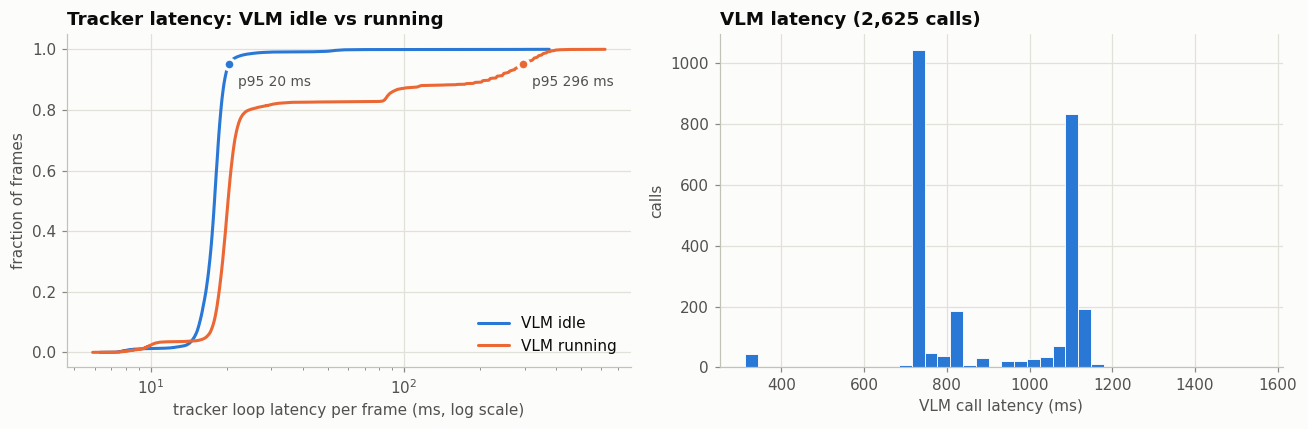

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
for (name, sub), color in zip((("VLM idle", frames[~frames["vlm_busy"]]), ("VLM running", frames[frames["vlm_busy"]])), SERIES):
    x = np.sort(sub["tracking_latency_ms"].values)
    ax.plot(x, np.arange(1, len(x) + 1) / len(x), color=color, label=name)
    p95 = np.quantile(x, 0.95)
    ax.plot([p95], [0.95], "o", ms=7, color=color, mec="#fcfcfb", mew=2)
    ax.annotate(f"p95 {p95:.0f} ms", (p95, 0.95), xytext=(6, -14), textcoords="offset points", fontsize=9, color=INK2)
ax.set_xscale("log"); ax.set_xlabel("tracker loop latency per frame (ms, log scale)"); ax.set_ylabel("fraction of frames")
ax.set_title("Tracker latency: VLM idle vs running"); ax.legend(loc="lower right")
ax = axes[1]
ax.hist(vlm, bins=40, color=SERIES[0], edgecolor="#fcfcfb", linewidth=0.6)
ax.set_xlabel("VLM call latency (ms)"); ax.set_ylabel("calls"); ax.set_title(f"VLM latency ({len(vlm):,} calls)")
plt.tight_layout(); fig.savefig(FIG / "async_latency.png"); plt.show()

**Reading the telemetry.**

* When the VLM is idle the tracker is fast and steady: p50 18 ms and p95 20 ms, comfortably inside the 33 ms budget of a 30 fps camera.
* The VLM was called 2,625 times, once every ~30 frames. Each call takes ~0.8–1.1 s, so the model is running for roughly half of all frames. The
  original summary (`src/calculate_benchmarks.py`) reports a "3.3% duty cycle", but that is the share of frames that *triggered* a call, not the time the VLM spends computing.
* The asynchronous design stops the tracker from blocking, but the two models share one GPU. While the VLM runs, tracker p95 rises from 20 ms to ~300 ms.
  Next steps: CUDA stream priorities, a separate device or a TensorRT-LLM engine for the VLM (a bf16 engine was built; the INT8 build did not complete), rate-limiting triggers, and resetting tracker state between videos.

*Tracker overlay on JAAD video 0135: YOLO11s person tracks, VLM status (COMPUTING) and the latest plan.*

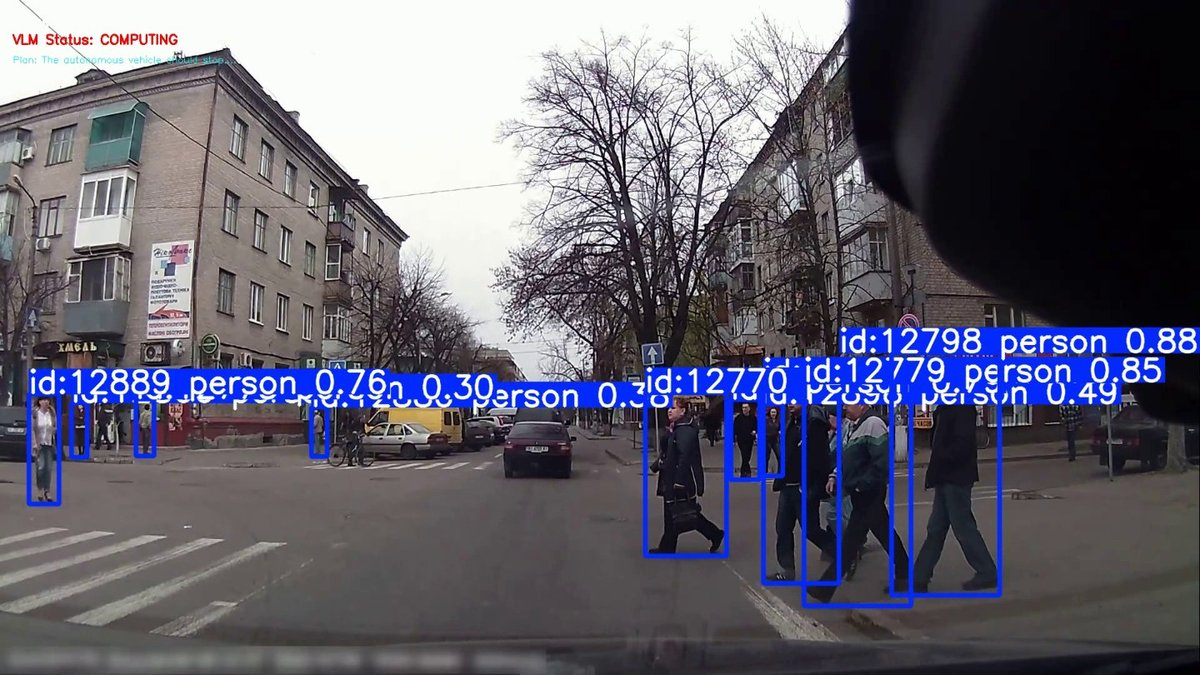

In [11]:
show(FIG / "tracked_frame_0135.jpg", width=1200, caption="Tracker overlay on JAAD video 0135: YOLO11s person tracks, VLM status (COMPUTING) and the latest plan.")

## 5 · Summary

| Component | Status |
|---|---|
| Dataset builder (655 annotated clips, context prompts, JSON targets) | done. Confidence field is random and reasoning is templated |
| QLoRA fine-tune of Qwen2-VL-2B | done. Output schema learned (100% valid JSON) |
| Intent accuracy on held-out clips | **not better than majority baseline**: balanced accuracy 0.52 |
| Async tracker + VLM architecture with telemetry | done. Non-blocking, but GPU contention inflates tracker tail latency ~14× |